# Tutorial 4: Neural Networks in Practice — Predicting Toxicity with Tox21

This notebook is the hands-on companion to **Neural Networks and Deep Learning**.

## Learning goals
- Get to know the **Tox21** toxicity dataset and why its labels are sparse
- Visualize a molecular featurization (Morgan fingerprints) and sanity-check it before training on it
- Build an MLP from scratch in PyTorch: forward pass, loss, backpropagation, optimizer updates
- Train a baseline model on one Tox21 task, then question whether a bigger model is justified by the dataset size
- Compare learning curves across hyperparameters and run a hyperparameter search
- Use a **fixed train/val/test split** for fair comparisons, and export a standardized payload for the class Pareto-front analysis
- **Advanced**: extend the model to multi-task learning across several Tox21 assays at once

The notebook is organized as a series of exercises. Each exercise states a short task.

**This is the solutions notebook** — the code cell(s) right after each exercise already contain a worked solution. Read them, run them, and tweak the parameters called out in each exercise to build intuition. A blank version of this notebook (`mlp-formation-energy.ipynb`), with the exercise cells left for you to fill in, is also available.

---
## References & tools used

This notebook builds on and credits:

- **Tox21 dataset** — a US EPA/NIH/FDA collaborative screening of ~8,000 compounds against 12 nuclear-receptor and stress-response assays (the "Tox21 Data Challenge", 2014).
- **DeepChem** (`dc.molnet.load_tox21`) — used once, offline, in `neural-networks-mlp/build_dataset.py` to fetch and flatten the raw Tox21 labels into `dataset.csv`. Students don't need DeepChem installed to run this notebook. Ramsundar et al., *Deep Learning for the Life Sciences*, O'Reilly, 2019 — https://deepchem.io
- **RDKit** — used throughout for parsing SMILES and computing Morgan/ECFP fingerprints — https://www.rdkit.org
- **scikit-learn** — PCA, k-NN, feature scaling, ROC-AUC / ROC-curve metrics.
- **PyTorch** — the MLP model, training loop, and autograd.
- **`molecular-representations.ipynb`** (this bootcamp, Tutorial 1) — the `morgan_matrix` fingerprint helper and the chemical-space PCA visualization pattern used in Exercise 2 are adapted from that notebook's featurization sections.
- **Kaggle — ["Molecular Toxicity Prediction using ML"](https://www.kaggle.com/code/gyanendrachaubey/molecular-toxicity-prediction-using-ml)** by gyanendrachaubey — inspiration for the missing-label heatmap (Exercise 1) and the ROC-curve evaluation plot (Exercise 8), both common EDA/evaluation views for Tox21-style multi-assay toxicity data.

In [1]:
# --- Cell: dependency installation ---
# If needed, install common dependencies.
# In most Colab runtimes these are already available; running this is a no-op there.
# If you're running locally, make sure you've created and activated the conda
# environment described in environment.yml (repo root) instead of relying on this line.
# %pip install -q pandas numpy matplotlib scikit-learn torch rdkit

In [2]:
# --- Cell: imports, random seed, and compute device ---
# Everything used later in the notebook is imported here in one place:
# - stdlib utilities (json/time/random/dataclasses/datetime/pathlib) for config,
#   timing, and writing the leaderboard payload
# - numpy/pandas for data handling, matplotlib for plots
# - RDKit for turning SMILES into Morgan fingerprints (Exercise 2)
# - scikit-learn for PCA/k-NN/scaling/metrics
# - torch for building and training the neural network

import json
import time
import random
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Fix every source of randomness (Python, NumPy, PyTorch) so that re-running this
# notebook reproduces the same weight initialization, batch shuffling, etc.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU automatically if one is available (e.g. on Colab), otherwise fall back to CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# --- Cell: locate the tutorial data, whether running on Colab or locally ---
# This notebook needs to find the `neural-networks-mlp/` data folder (dataset.csv +
# splits/ + leaderboard/). Its location differs between environments:
# - Locally: you're expected to launch Jupyter from inside `tutorials/`, so it's
#   already in the current working directory.
# - On Colab: nothing is checked out by default, so we clone the bootcamp repo
#   into /content and point the working directory there.
# The logic below tries a few known locations first, and only clones the repo
# (network operation) as a last resort when running on Colab.
import os
import sys
from pathlib import Path

REQUIRED_DATA_REL = Path("neural-networks-mlp/dataset.csv")
CANDIDATE_REPO_URLS = [
    "https://github.com/truejulosdu13/ai4chemistry-bootcamp.git",
    "https://github.com/julschleinitz/ai4chemistry-bootcamp.git",
]

candidate_tutorial_dirs = [
    Path.cwd(),
    Path("/content/ai4chemistry-bootcamp/tutorials"),
    Path("/content/ai4chemistry-bootcamp/website/tutorials"),
]

def _find_tutorial_dir(candidates):
    """Return the first candidate directory that already contains the required
    dataset file, or None if none of them do."""
    for d in candidates:
        if (d / REQUIRED_DATA_REL).exists():
            return d
    return None

tutorial_dir = _find_tutorial_dir(candidate_tutorial_dirs)

# If not found and running in Colab, clone automatically.
if tutorial_dir is None and "google.colab" in sys.modules:
    clone_root = Path("/content/ai4chemistry-bootcamp")
    if not clone_root.exists():
        clone_ok = False
        for repo_url in CANDIDATE_REPO_URLS:
            exit_code = os.system(f"git clone {repo_url} {clone_root}")
            if exit_code == 0:
                clone_ok = True
                break
        if not clone_ok:
            raise RuntimeError("Failed to clone bootcamp repository in Colab.")

    candidate_tutorial_dirs = [
        Path("/content/ai4chemistry-bootcamp/tutorials"),
        Path("/content/ai4chemistry-bootcamp/website/tutorials"),
        Path.cwd(),
    ]
    tutorial_dir = _find_tutorial_dir(candidate_tutorial_dirs)

if tutorial_dir is None:
    raise FileNotFoundError(
        "Could not find neural-networks-mlp/dataset.csv. "
        "Set your working directory to the tutorials folder containing neural-networks-mlp/. "
        f"Current directory: {Path.cwd()}"
    )

# Every relative path later in the notebook (PathsConfig) assumes this directory.
os.chdir(tutorial_dir)
print(f"Working directory set to: {Path.cwd()}")
print(f"Found data root at: {Path.cwd() / 'neural-networks-mlp'}")

Working directory set to: /Users/julesschleinitz/Desktop/MLChem Bootcamp/website/tutorials
Found data root at: /Users/julesschleinitz/Desktop/MLChem Bootcamp/website/tutorials/neural-networks-mlp


In [4]:
# --- Cell: configuration and file-existence check ---
# Two small config objects keep "where are the files" (PathsConfig) separate from
# "how should this run behave" (TutorialConfig), so you only need to touch one or
# the other depending on what you're changing.

@dataclass
class PathsConfig:
    """Paths to every file this notebook reads or writes, relative to the
    tutorial directory set up in the previous cell."""
    dataset_csv: str = "./neural-networks-mlp/dataset.csv"
    train_split_csv: str = "./neural-networks-mlp/splits/train.csv"
    val_split_csv: str = "./neural-networks-mlp/splits/val.csv"
    test_split_csv: str = "./neural-networks-mlp/splits/test.csv"
    schema_csv: str = "./neural-networks-mlp/leaderboard/results_schema.csv"
    helper_py: str = "./neural-networks-mlp/leaderboard/submit_payload.py"

@dataclass
class TutorialConfig:
    """Settings that control how the notebook runs, independent of file paths.
    `target_col` picks which of the 12 Tox21 assays is the running example for
    Exercises 4-8 — all 12 are loaded and stay available in `df` (see Exercise 1),
    so you can change this to explore a different assay. `student_or_team` is
    used to tag your leaderboard submission — edit it before running the final cells."""
    target_col: str = "SR-MMP"
    fp_radius: int = 2
    fp_n_bits: int = 2048
    split_version: str = "v1"
    metric_name: str = "roc_auc"
    notebook_version: str = "nn_tutorial_v2_tox21"
    student_or_team: str = "Team XX"

PATHS = PathsConfig()
CFG = TutorialConfig()

def validate_required_files(paths: PathsConfig):
    """Fail early with a clear message if any required data/leaderboard file is
    missing, instead of letting a cryptic error surface deep in the notebook."""
    required = [
        paths.dataset_csv,
        paths.train_split_csv,
        paths.val_split_csv,
        paths.test_split_csv,
        paths.schema_csv,
        paths.helper_py,
    ]
    missing = [p for p in required if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required tutorial files:\n"
            + "\n".join(f"- {p}" for p in missing)
            + f"\n\nCurrent working directory: {Path.cwd()}"
        )

validate_required_files(PATHS)
print(PATHS)
print(CFG)

PathsConfig(dataset_csv='./neural-networks-mlp/dataset.csv', train_split_csv='./neural-networks-mlp/splits/train.csv', val_split_csv='./neural-networks-mlp/splits/val.csv', test_split_csv='./neural-networks-mlp/splits/test.csv', schema_csv='./neural-networks-mlp/leaderboard/results_schema.csv', helper_py='./neural-networks-mlp/leaderboard/submit_payload.py')
TutorialConfig(target_col='SR-MMP', fp_radius=2, fp_n_bits=2048, split_version='v1', metric_name='roc_auc', notebook_version='nn_tutorial_v2_tox21', student_or_team='Team XX')


---
## Exercise 1 — Introduce the Tox21 dataset

**Tox21** ("Toxicology in the 21st Century") is a US EPA/NIH/FDA screening effort that tested ~8,000 compounds against 12 assays for nuclear-receptor signaling and cellular stress response (e.g. `NR-AR` = androgen receptor activation, `SR-p53` = p53 stress-response pathway). Each assay is a separate binary classification task: *does this compound trigger this specific biological response?*

Crucially, **not every compound was tested against every assay** — the label matrix is sparse. This matters both for picking a single "primary" task to train on (Exercises 3-8) and for the multi-task model later (Exercise 9), which has to learn from a matrix full of holes.

1. Load `dataset.csv` and look at its shape and columns — how many molecules, and what does each of the 12 task columns contain?
2. For each of the 12 tasks, compute how many molecules have a label at all, and what fraction of those are positive (toxic).
3. Visualize the missing-label pattern directly: for a sample of molecules, which of the 12 assays were they actually tested on?

In [5]:
# --- Exercise 1 solution: load the dataset and inspect its shape/columns ---
df = pd.read_csv(PATHS.dataset_csv)
TOX21_TASKS = [c for c in df.columns if c not in ("sample_id", "smiles")]

print(f"{len(df)} molecules, {len(TOX21_TASKS)} Tox21 tasks")
print("Tasks:", TOX21_TASKS)
df.head()

7823 molecules, 12 Tox21 tasks
Tasks: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


,sample_id,smiles,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,mol_000001,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,mol_000002,CCN1C(=O)NC(c2ccccc2)C1=O,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
2,mol_000003,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
3,mol_000004,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
4,mol_000005,CC(O)(P(=O)(O)O)P(=O)(O)O,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


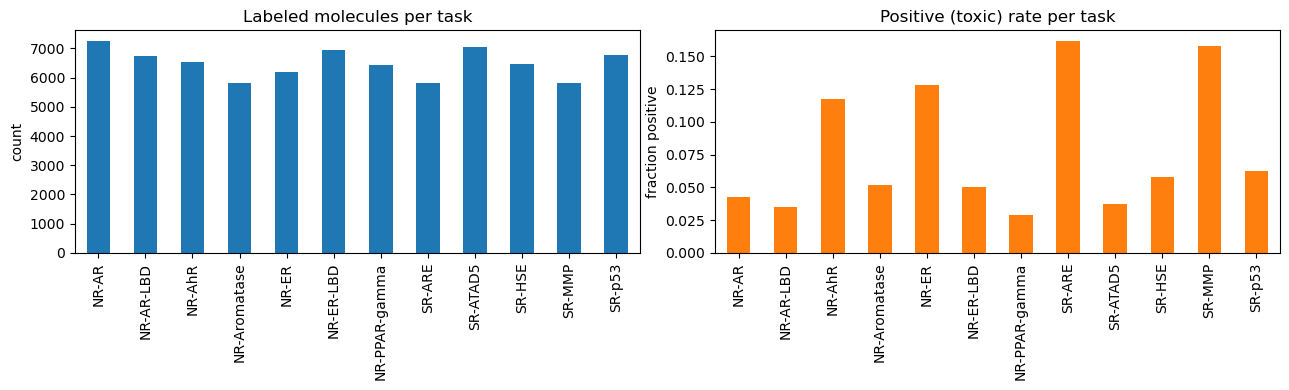

               n_labeled  positive_rate
NR-AR               7258          0.042
NR-AR-LBD           6751          0.035
NR-AhR              6542          0.117
NR-Aromatase        5815          0.052
NR-ER               6186          0.128
NR-ER-LBD           6948          0.050
NR-PPAR-gamma       6443          0.029
SR-ARE              5825          0.162
SR-ATAD5            7065          0.037
SR-HSE              6460          0.058
SR-MMP              5804          0.158
SR-p53              6767          0.063


In [6]:
# --- Exercise 1 solution: per-task label counts and positive rates ---

def plot_label_stats(df, tasks):
    """Bar charts of (a) how many molecules have a label for each task, and
    (b) what fraction of those labels are positive — the two numbers you need
    before picking a task to train on."""
    counts = df[tasks].notna().sum()
    pos_rate = df[tasks].apply(lambda c: (c == 1).sum() / c.notna().sum() if c.notna().sum() else np.nan)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    counts.plot(kind="bar", ax=ax[0], color="tab:blue")
    ax[0].set_title("Labeled molecules per task")
    ax[0].set_ylabel("count")

    pos_rate.plot(kind="bar", ax=ax[1], color="tab:orange")
    ax[1].set_title("Positive (toxic) rate per task")
    ax[1].set_ylabel("fraction positive")

    plt.tight_layout()
    plt.show()
    return counts, pos_rate

label_counts, positive_rates = plot_label_stats(df, TOX21_TASKS)
print(pd.DataFrame({"n_labeled": label_counts, "positive_rate": positive_rates.round(3)}))

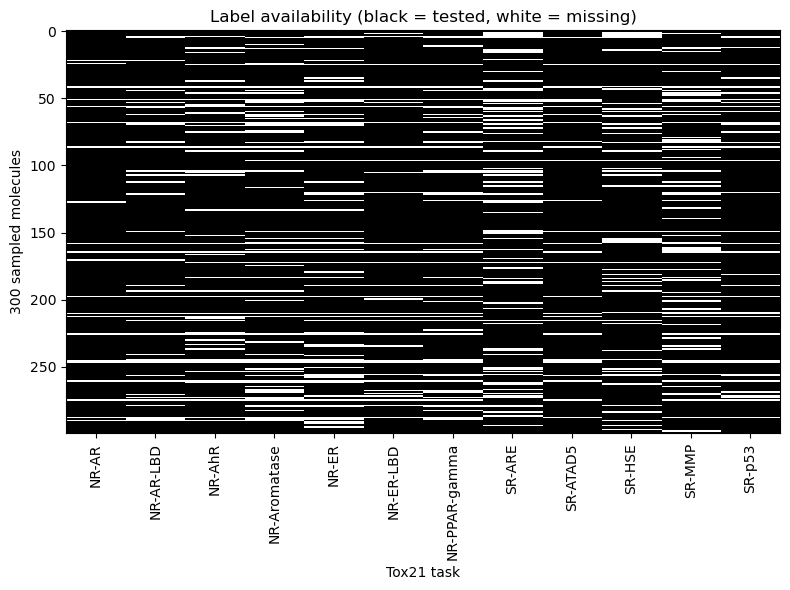


Running example for Exercises 3-8: CFG.target_col = 'SR-MMP'
  -> 5804 labeled molecules, 15.8% positive


In [7]:
# --- Exercise 1 solution: missing-label heatmap ---
# Plotting all ~7800 molecules would be an unreadable wall of pixels, so we
# subsample a readable number of rows just to show the missingness *pattern*
# (the counts above already give the full, exact picture).

def plot_missingness(df, tasks, n_show=300, seed=SEED):
    mat = df[tasks].notna().values.astype(int)  # 1 = tested, 0 = missing
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(mat), size=min(n_show, len(mat)), replace=False)

    plt.figure(figsize=(8, 6))
    plt.imshow(mat[idx], aspect="auto", cmap="Greys", interpolation="nearest")
    plt.xticks(range(len(tasks)), tasks, rotation=90)
    plt.xlabel("Tox21 task")
    plt.ylabel(f"{len(idx)} sampled molecules")
    plt.title("Label availability (black = tested, white = missing)")
    plt.tight_layout()
    plt.show()

plot_missingness(df, TOX21_TASKS)
print(f"\nRunning example for Exercises 3-8: CFG.target_col = {CFG.target_col!r}")
print(f"  -> {label_counts[CFG.target_col]} labeled molecules, {positive_rates[CFG.target_col]:.1%} positive")

---
## Exercise 2 — Visualize and choose a featurization

An MLP needs a fixed-length numeric vector per molecule, not a SMILES string. We'll use **Morgan fingerprints** (a.k.a. ECFP): for each atom, hash its local neighborhood (up to `radius` bonds away) into one of `n_bits` positions — the result is a fixed-length bit vector that captures which substructures are present, without needing 3D structure or a trained embedding model.

1. Compute a Morgan fingerprint matrix (`radius=2`, `n_bits=2048`) for every molecule's SMILES.
2. Project it to 2D with PCA and plot it, colored by the primary task's label (`CFG.target_col`) — do toxic and non-toxic molecules separate at all in fingerprint space?
3. Sanity-check the featurization quantitatively: does a simple k-NN classifier trained directly on the fingerprints do better than chance at predicting the label?
4. Attach the resulting `fp_0..fp_{n_bits-1}` columns to `df` so later exercises can use them as model input.

In [8]:
# --- Exercise 2 solution: Morgan fingerprints from SMILES ---
# Adapted from `morgan_matrix` in molecular-representations.ipynb (Tutorial 1).

def morgan_matrix(smiles_list, radius=2, n_bits=2048):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fp = generator.GetFingerprint(mol)
            arr = np.zeros(n_bits, dtype=np.uint8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
        else:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
    return np.array(fps)

X_fp = morgan_matrix(df["smiles"], radius=CFG.fp_radius, n_bits=CFG.fp_n_bits)
print(f"Fingerprint matrix shape: {X_fp.shape}")
print(f"Average bit density: {X_fp.mean() * 100:.1f}%")

Fingerprint matrix shape: (7823, 2048)
Average bit density: 1.5%


[21:15:49] WARNING: not removing hydrogen atom without neighbors


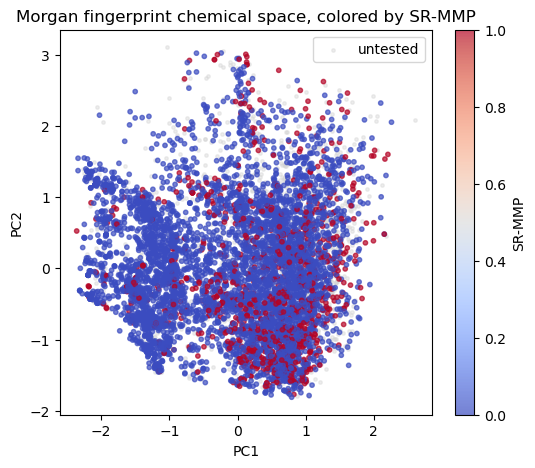

In [9]:
# --- Exercise 2 solution: chemical-space PCA plot, colored by the primary task ---
# Adapted from `project_2d`/`plot_chemical_space` in molecular-representations.ipynb,
# simplified to a static matplotlib scatter (no Bokeh dependency needed here).

def plot_chemical_space(X, labels, title):
    coords = PCA(n_components=2, random_state=SEED).fit_transform(np.nan_to_num(X, nan=0.0))
    labels = np.asarray(labels, dtype=float)
    tested = ~np.isnan(labels)

    plt.figure(figsize=(6, 5))
    plt.scatter(coords[~tested, 0], coords[~tested, 1], c="lightgray", s=6, alpha=0.4, label="untested")
    sc = plt.scatter(coords[tested, 0], coords[tested, 1], c=labels[tested], cmap="coolwarm", s=10, alpha=0.7)
    plt.colorbar(sc, label=CFG.target_col)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.show()

plot_chemical_space(X_fp, df[CFG.target_col].values, title=f"Morgan fingerprint chemical space, colored by {CFG.target_col}")

In [10]:
# --- Exercise 2 solution: quick k-NN quality check for this featurization ---

def evaluate_representation_knn(X, y, k=5, test_size=0.2, random_state=SEED):
    """Fit a k-NN classifier on a random split of `X`/`y` and report test ROC-AUC —
    a cheap way to check the featurization captures signal, before spending time
    training a neural network on it."""
    y = np.asarray(y, dtype=float)
    labeled = ~np.isnan(y)
    X, y = X[labeled], y[labeled]

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)
    probs = knn.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, probs)
    print(f"k-NN (k={k}, random split) on Morgan fingerprints — Test ROC-AUC: {auc:.3f}")
    return auc

_ = evaluate_representation_knn(X_fp, df[CFG.target_col].values)

k-NN (k=5, random split) on Morgan fingerprints — Test ROC-AUC: 0.747


In [11]:
# --- Exercise 2 solution: attach the fingerprint columns to df ---
# Later exercises (starting with Exercise 4's `load_fixed_splits`) look for
# columns prefixed with "fp_" as model input features.
fp_cols = [f"fp_{i}" for i in range(X_fp.shape[1])]
df = pd.concat([df.reset_index(drop=True), pd.DataFrame(X_fp, columns=fp_cols)], axis=1)
print(f"df now has {df.shape[1]} columns ({len(fp_cols)} fingerprint features + {len(TOX21_TASKS)} task labels + sample_id/smiles)")

df now has 2062 columns (2048 fingerprint features + 12 task labels + sample_id/smiles)


---
## Exercise 3 — Introduce the neural network

### 3a. The simplest possible network

Before building a configurable model, look at the simplest neural network that improves on a plain linear model — a single hidden layer, exactly like the introductory example in dmol.pub's *Deep Learning for Molecules and Materials* (Section C.6, https://dmol.pub/dl/introduction.html). It replaces the raw feature vector with **one trainable nonlinear transformation** g(x) = tanh(W0 x + b0), and then reads out a single value with a linear layer:

`Input -> Dense(D -> 32) -> Tanh -> Dense(32 -> 1) -> Output`

1. Build this exact architecture with `nn.Sequential` and run it on a small batch of Morgan fingerprints from Exercise 2, just to confirm the input/output shapes make sense (we train it for real using the machinery built in Exercise 4).
2. This network is fixed: exactly **one** hidden layer, exactly **32** units, always `tanh`, no regularization. Exercises 5-9 need to compare depth/width (Exercise 5), compare other hyperparameters (Exercises 6-7), and eventually predict several tasks at once (Exercise 9) — none of that is possible if those choices are hard-coded. What would need to change to make this configurable?

### 3b. Generalizing it: `MolecularMLP`

`MolecularMLP` below is exactly that generalization: the same `Linear -> activation -> (Dropout)` block from 3a, just repeated `hidden_layers` times with a configurable `hidden_width`, a choice of `activation`, optional `dropout` for regularization, and a configurable number of outputs (`out_dim`, used for multi-task learning in Exercise 9).

3. Read through `MolecularMLP` — what does each constructor argument (`hidden_layers`, `hidden_width`, `dropout`, `activation`) control, and how does setting `hidden_layers=1, hidden_width=32, dropout=0, activation="tanh"` recover the simple network from 3a?
4. Instantiate a small one and check `count_params` — how many trainable parameters does a `hidden_layers=2, hidden_width=128` network have, versus `hidden_layers=4, hidden_width=512`? Keep this number in mind for Exercise 5.

In [12]:
# --- Exercise 3a solution: the simplest possible network (dmol.pub-style) ---
# One hidden layer, fixed width, fixed activation — a direct PyTorch translation
# of g(x) = tanh(W0 x + b0) followed by a linear read-out.

simple_net = nn.Sequential(
    nn.Linear(CFG.fp_n_bits, 32),
    nn.Tanh(),
    nn.Linear(32, 1),
).to(DEVICE)
print(simple_net)

# Sanity-check the forward pass on a small batch of fingerprints from Exercise 2 —
# no training yet, just confirming shapes (the training loop comes in Exercise 4).
sample_batch = torch.tensor(X_fp[:8], dtype=torch.float32).to(DEVICE)
sample_out = simple_net(sample_batch)
print(f"Input shape: {tuple(sample_batch.shape)} -> output shape: {tuple(sample_out.shape)}")

Sequential(
  (0): Linear(in_features=2048, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=1, bias=True)
)
Input shape: (8, 2048) -> output shape: (8, 1)


In [13]:
# --- Exercise 3b solution: generalizing simple_net into a configurable MLP ---
# `out_dim` defaults to 1 (one task) but Exercise 9 reuses this same class with
# `out_dim=len(TOX21_TASKS)` for multi-task learning — no separate model class needed.

class MolecularMLP(nn.Module):
    """A configurable feed-forward network mapping a fixed-length feature
    vector (fingerprint bits, descriptors, ...) to `out_dim` scalar outputs.

    Args:
        in_dim: number of input features.
        hidden_layers: how many hidden Linear+activation blocks to stack.
        hidden_width: number of units in each hidden layer.
        dropout: dropout probability applied after each hidden activation
            (0 disables dropout entirely).
        activation: one of "relu", "gelu", "tanh".
        out_dim: number of output logits (1 for single-task, n_tasks for multi-task).
    """
    def __init__(self, in_dim, hidden_layers, hidden_width, dropout, activation, out_dim=1):
        super().__init__()
        act_map = {
            "relu": nn.ReLU,
            "gelu": nn.GELU,
            "tanh": nn.Tanh,
        }
        if activation not in act_map:
            raise ValueError(f"Unsupported activation: {activation}")

        layers = []
        prev_dim = in_dim
        for _ in range(hidden_layers):
            layers.append(nn.Linear(prev_dim, hidden_width))
            layers.append(act_map[activation]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_width

        layers.append(nn.Linear(prev_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """Run the forward pass: x -> hidden layers -> out_dim outputs per row."""
        return self.net(x)

def count_params(model):
    """Total number of trainable parameters in `model` (used to compare model
    complexity across hyperparameter configurations)."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

small = MolecularMLP(in_dim=CFG.fp_n_bits, hidden_layers=2, hidden_width=128, dropout=0.1, activation="relu")
large = MolecularMLP(in_dim=CFG.fp_n_bits, hidden_layers=4, hidden_width=512, dropout=0.1, activation="relu")
print(f"hidden_layers=2, hidden_width=128  -> {count_params(small):,} parameters")
print(f"hidden_layers=4, hidden_width=512  -> {count_params(large):,} parameters")

hidden_layers=2, hidden_width=128  -> 278,913 parameters
hidden_layers=4, hidden_width=512  -> 1,837,569 parameters


---
## Exercise 4 — Train a model on one Tox21 task

Time to put the pieces together: load the fixed train/val/test split for `CFG.target_col`, build the training loop (forward pass, loss, backward pass, optimizer step), and train one baseline configuration end to end.

Recall the **fixed split policy**: `splits/train.csv`, `val.csv`, `test.csv` were published once by the instructor (see `neural-networks-mlp/splits/README.md`) — never re-split the data yourself, and never use the test split for anything except a final, one-time evaluation.

1. Load the fixed splits for `CFG.target_col`, dropping molecules that were never tested on it.
2. Train a single baseline MLP configuration and plot its training/validation loss and validation ROC-AUC over epochs.
3. Report its test ROC-AUC — this is the number every later exercise tries to beat.

In [14]:
# --- Exercise 4 solution: load the fixed split for the primary task ---

def _read_split_ids(path):
    """Read a split CSV (one `sample_id` column) and return its ids as a set of
    strings, for fast membership checks."""
    split_df = pd.read_csv(path)
    if "sample_id" not in split_df.columns:
        raise ValueError(f"Split file {path} must contain a 'sample_id' column")
    return set(split_df["sample_id"].astype(str).tolist())

def load_fixed_splits(df, train_csv, val_csv, test_csv, target_col):
    """Slice `df` (already featurized with fp_ columns, Exercise 2) into
    train/val/test using the fixed split files, dropping molecules with no
    label for `target_col`, then standardize features (fit on train only, so
    val/test statistics never leak into the scaler)."""
    df = df.copy()
    df["sample_id"] = df["sample_id"].astype(str)
    df = df.dropna(subset=[target_col]).reset_index(drop=True)

    train_ids = _read_split_ids(train_csv)
    val_ids = _read_split_ids(val_csv)
    test_ids = _read_split_ids(test_csv)

    # Splits must partition the data with no overlap — otherwise "held-out" test
    # performance would be contaminated by samples seen during training.
    if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
        raise ValueError("Split overlap detected. Splits must be disjoint.")

    feature_cols = [c for c in df.columns if c.startswith("fp_")]
    if not feature_cols:
        raise ValueError("No fp_ feature columns found — run Exercise 2 first.")

    train_df = df[df["sample_id"].isin(train_ids)].copy()
    val_df = df[df["sample_id"].isin(val_ids)].copy()
    test_df = df[df["sample_id"].isin(test_ids)].copy()

    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if split_df.empty:
            raise ValueError(f"{split_name} split is empty after filtering missing {target_col} labels.")

    x_train = train_df[feature_cols].values.astype(np.float32)
    x_val = val_df[feature_cols].values.astype(np.float32)
    x_test = test_df[feature_cols].values.astype(np.float32)

    y_train = train_df[target_col].values.astype(np.float32)
    y_val = val_df[target_col].values.astype(np.float32)
    y_test = test_df[target_col].values.astype(np.float32)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_test = scaler.transform(x_test)

    return {
        "feature_cols": feature_cols,
        "train": (x_train, y_train, train_df["sample_id"].tolist()),
        "val": (x_val, y_val, val_df["sample_id"].tolist()),
        "test": (x_test, y_test, test_df["sample_id"].tolist()),
    }

split_data = load_fixed_splits(df, PATHS.train_split_csv, PATHS.val_split_csv, PATHS.test_split_csv, CFG.target_col)
x_train, y_train, train_ids = split_data["train"]
x_val, y_val, val_ids = split_data["val"]
x_test, y_test, test_ids = split_data["test"]

print(f"Fixed splits for target_col={CFG.target_col!r}:")
print(f"  train: {x_train.shape}, val: {x_val.shape}, test: {x_test.shape}")

Fixed splits for target_col='SR-MMP':
  train: (4062, 2048), val: (871, 2048), test: (871, 2048)


In [15]:
# --- Exercise 4 solution: tensors and DataLoaders ---
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)

def make_loaders(batch_size):
    """Wrap the train/val/test tensors in DataLoaders with the given batch size.
    Only the training loader shuffles — val/test order doesn't matter and keeping
    it fixed makes debugging easier."""
    train_ds = TensorDataset(x_train_t, y_train_t)
    val_ds = TensorDataset(x_val_t, y_val_t)
    test_ds = TensorDataset(x_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [16]:
# --- Exercise 4 solution: one training epoch, evaluation, and the full training loop ---

def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full pass over `loader`: for each batch, compute the loss
    (forward pass), backpropagate gradients, and update the weights
    (optimizer step). Returns the average loss over the epoch."""
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()          # clear gradients from the previous step
        logits = model(xb)             # forward pass
        loss = criterion(logits, yb)
        loss.backward()                # backpropagation: compute gradients
        optimizer.step()               # apply the gradient update
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    """Run `model` over `loader` in evaluation mode (no gradient tracking,
    dropout disabled) and return the average loss, ROC-AUC, and the raw
    true/predicted arrays (useful for later plotting/inspection)."""
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits)
        y_pred.extend(probs.cpu().numpy().reshape(-1).tolist())
        y_true.extend(yb.cpu().numpy().reshape(-1).tolist())

    avg_loss = total_loss / len(loader.dataset)
    score = roc_auc_score(y_true, y_pred)
    return avg_loss, score, np.asarray(y_true), np.asarray(y_pred)

def run_experiment(config):
    """Train and evaluate one MolecularMLP configuration end-to-end: build data
    loaders and model, train with early stopping on validation ROC-AUC, restore
    the best validation checkpoint, and score it once on the held-out test set.

    `config` is a dict of hyperparameters (hidden_layers, hidden_width,
    activation, dropout, optimizer, learning_rate, batch_size, weight_decay,
    epochs, early_stop_patience).
    """
    train_loader, val_loader, test_loader = make_loaders(config["batch_size"])

    model = MolecularMLP(
        in_dim=x_train.shape[1],
        hidden_layers=config["hidden_layers"],
        hidden_width=config["hidden_width"],
        dropout=config["dropout"],
        activation=config["activation"],
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    if config["optimizer"] == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    elif config["optimizer"] == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=config["learning_rate"], momentum=0.9, weight_decay=config["weight_decay"])
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

    best_state = None
    best_val_score = -np.inf  # ROC-AUC: higher is better
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_score": []}

    start_time = time.time()
    for epoch in range(config["epochs"]):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_score, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_score"].append(val_score)

        if val_score > best_val_score:
            # Checkpoint the best-so-far weights so we can roll back to them
            # after training finishes, even if later epochs overfit.
            best_val_score = val_score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        # Early stopping: stop once validation performance hasn't improved for
        # `early_stop_patience` epochs in a row, to save time and avoid overfitting.
        if no_improve >= config["early_stop_patience"]:
            break

    train_time_sec = time.time() - start_time
    if best_state is not None:
        model.load_state_dict(best_state)

    # Test score is computed exactly once, on the best validation checkpoint —
    # never used to pick hyperparameters.
    test_loss, test_score, y_true_test, y_pred_test = evaluate(model, test_loader, criterion)

    return {
        "model": model,
        "history": history,
        "train_time_sec": train_time_sec,
        "best_val_score": best_val_score,
        "test_score": test_score,
        "test_loss": test_loss,
        "y_true_test": y_true_test,
        "y_pred_test": y_pred_test,
        "epochs_trained": len(history["train_loss"]),
        "param_count": count_params(model),
    }

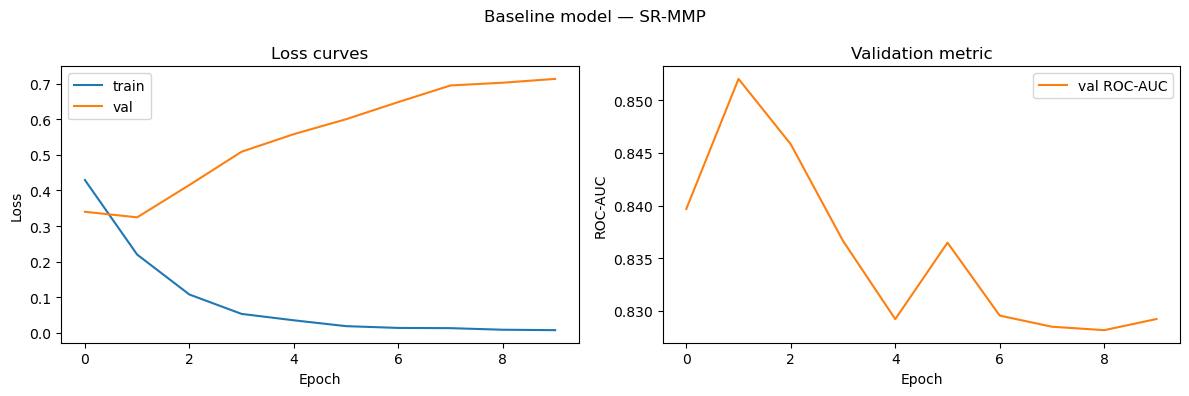

Baseline test ROC-AUC: 0.858
Parameters: 278,913, epochs trained: 10


In [17]:
# --- Exercise 4 solution: plot learning curves, and train the baseline model ---

def plot_learning_curves(history, title):
    """Plot the loss curves (train vs. val) side by side with the validation
    ROC-AUC, both over training epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history["train_loss"], label="train")
    ax[0].plot(history["val_loss"], label="val")
    ax[0].set_title("Loss curves")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(history["val_score"], label="val ROC-AUC", color="tab:orange")
    ax[1].set_title("Validation metric")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("ROC-AUC")
    ax[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

baseline_config = {
    "hidden_layers": 2, "hidden_width": 128, "activation": "relu", "dropout": 0.1,
    "optimizer": "adam", "learning_rate": 1e-3, "batch_size": 128, "weight_decay": 1e-4,
    "epochs": 40, "early_stop_patience": 8,
}
baseline_result = run_experiment(baseline_config)
plot_learning_curves(baseline_result["history"], title=f"Baseline model — {CFG.target_col}")
print(f"Baseline test ROC-AUC: {baseline_result['test_score']:.3f}")
print(f"Parameters: {baseline_result['param_count']:,}, epochs trained: {baseline_result['epochs_trained']}")

---
## Exercise 5 — Question the NN architecture in light of the dataset size

`load_fixed_splits` reported the training set size for `CFG.target_col` above — likely a few thousand molecules. A `hidden_layers=4, hidden_width=512` MLP has hundreds of thousands of parameters (Exercise 3). When the parameter count starts to rival (or exceed) the number of training examples, a model can memorize the training set instead of generalizing — you'd see training loss keep dropping while validation loss stalls or rises.

1. Train three MLPs that only differ in capacity (`tiny` / `medium` / `large` — same everything else), and record their parameter count alongside val/test ROC-AUC.
2. Plot parameter count against test score, and against the train/val loss gap — does a bigger model actually help here, or does it just overfit faster?

In [18]:
# --- Exercise 5 solution: capacity sweep at fixed dataset size ---
capacity_configs = [
    {"label": "tiny",   "hidden_layers": 1, "hidden_width": 32},
    {"label": "medium", "hidden_layers": 2, "hidden_width": 128},
    {"label": "large",  "hidden_layers": 4, "hidden_width": 512},
]
capacity_defaults = {
    "activation": "relu", "dropout": 0.1, "optimizer": "adam", "learning_rate": 1e-3,
    "batch_size": 128, "weight_decay": 1e-4, "epochs": 40, "early_stop_patience": 8,
}

capacity_rows = []
for cfg in capacity_configs:
    full_config = {**capacity_defaults, **{k: v for k, v in cfg.items() if k != "label"}}
    result = run_experiment(full_config)
    train_val_gap = result["history"]["val_loss"][-1] - result["history"]["train_loss"][-1]
    capacity_rows.append({
        "label": cfg["label"],
        "hidden_layers": cfg["hidden_layers"],
        "hidden_width": cfg["hidden_width"],
        "param_count": result["param_count"],
        "best_val_score": result["best_val_score"],
        "test_score": result["test_score"],
        "train_val_loss_gap": train_val_gap,
    })
    print(f"{cfg['label']:>6}: {result['param_count']:>7,} params -> val AUC {result['best_val_score']:.3f}, test AUC {result['test_score']:.3f}, train/val loss gap {train_val_gap:+.3f}")

capacity_df = pd.DataFrame(capacity_rows)
capacity_df

  tiny:  65,601 params -> val AUC 0.849, test AUC 0.843, train/val loss gap +0.399


medium: 278,913 params -> val AUC 0.856, test AUC 0.869, train/val loss gap +0.738


 large: 1,837,569 params -> val AUC 0.854, test AUC 0.866, train/val loss gap +0.915


,label,hidden_layers,hidden_width,param_count,best_val_score,test_score,train_val_loss_gap
0,tiny,1,32,65601,0.848844,0.842814,0.398704
1,medium,2,128,278913,0.855685,0.868517,0.737832
2,large,4,512,1837569,0.854420,0.865818,0.915385


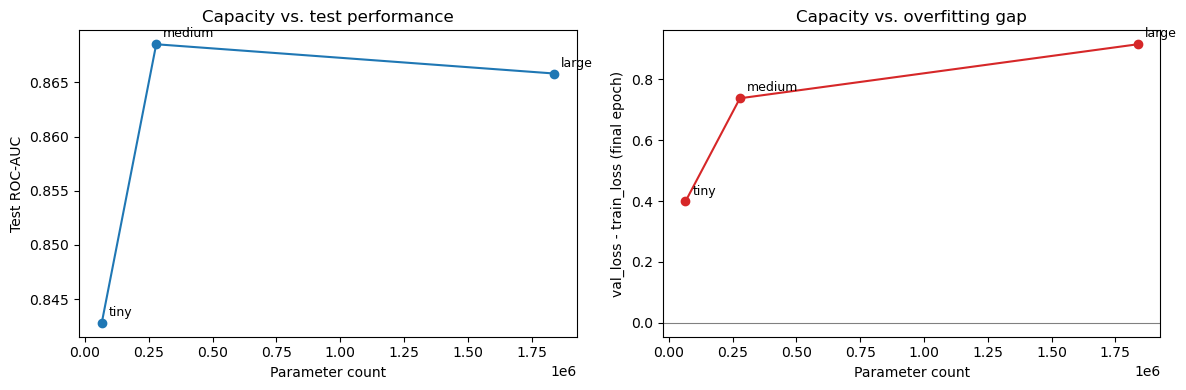

In [19]:
# --- Exercise 5 solution: parameter count vs. test score and overfitting gap ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(capacity_df["param_count"], capacity_df["test_score"], "o-", color="tab:blue")
for _, row in capacity_df.iterrows():
    ax[0].annotate(row["label"], (row["param_count"], row["test_score"]), fontsize=9, xytext=(5, 5), textcoords="offset points")
ax[0].set_xlabel("Parameter count")
ax[0].set_ylabel("Test ROC-AUC")
ax[0].set_title("Capacity vs. test performance")

ax[1].plot(capacity_df["param_count"], capacity_df["train_val_loss_gap"], "o-", color="tab:red")
for _, row in capacity_df.iterrows():
    ax[1].annotate(row["label"], (row["param_count"], row["train_val_loss_gap"]), fontsize=9, xytext=(5, 5), textcoords="offset points")
ax[1].set_xlabel("Parameter count")
ax[1].set_ylabel("val_loss - train_loss (final epoch)")
ax[1].set_title("Capacity vs. overfitting gap")
ax[1].axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

---
## Exercise 6 — Visualize learning curves with regard to hyperparameters

Beyond capacity, other hyperparameters change *how* training unfolds — not just the final score. The learning rate is a good one to isolate: too high and training can oscillate or diverge, too low and it may not converge within the epoch budget.

1. Fix the architecture at the `medium` configuration from Exercise 5.
2. Train three models that only differ in `learning_rate` (`1e-2`, `1e-3`, `1e-4`).
3. Overlay their validation ROC-AUC curves (and validation loss curves) on the same axes — what does each learning rate's curve shape tell you?

learning_rate=0.01     -> val AUC 0.842, test AUC 0.829, epochs 10


learning_rate=0.001    -> val AUC 0.854, test AUC 0.856, epochs 10


learning_rate=0.0001   -> val AUC 0.860, test AUC 0.852, epochs 19


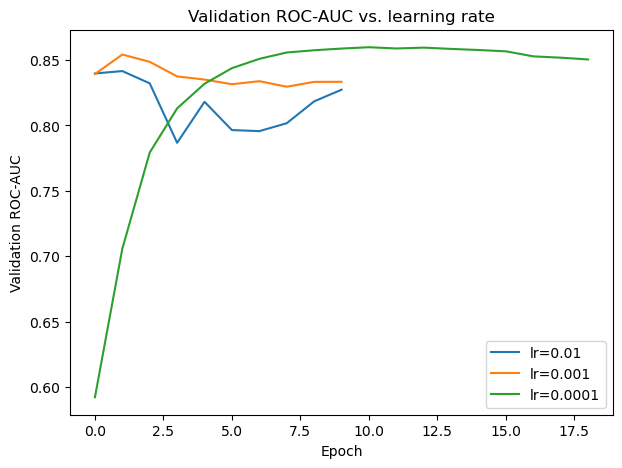

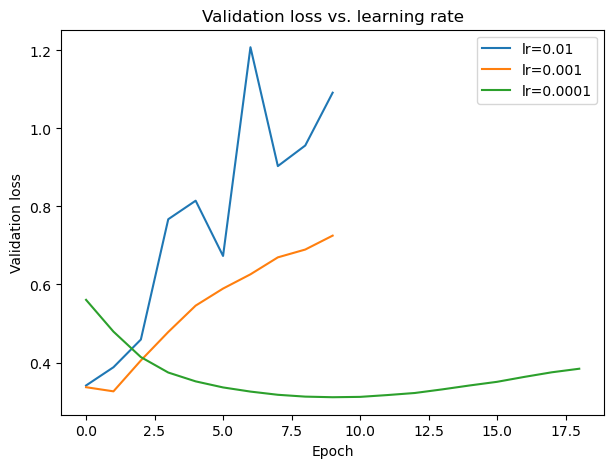

In [20]:
# --- Exercise 6 solution: overlaid learning curves across learning rates ---

def plot_overlaid_curves(histories, labels, key, ylabel, title):
    plt.figure(figsize=(7, 5))
    for history, label in zip(histories, labels):
        plt.plot(history[key], label=label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

lr_values = [1e-2, 1e-3, 1e-4]
lr_defaults = {
    "hidden_layers": 2, "hidden_width": 128, "activation": "relu", "dropout": 0.1,
    "optimizer": "adam", "batch_size": 128, "weight_decay": 1e-4,
    "epochs": 40, "early_stop_patience": 8,
}

lr_results = []
for lr in lr_values:
    result = run_experiment({**lr_defaults, "learning_rate": lr})
    lr_results.append(result)
    print(f"learning_rate={lr:<8} -> val AUC {result['best_val_score']:.3f}, test AUC {result['test_score']:.3f}, epochs {result['epochs_trained']}")

lr_labels = [f"lr={lr}" for lr in lr_values]
plot_overlaid_curves([r["history"] for r in lr_results], lr_labels, key="val_score", ylabel="Validation ROC-AUC", title="Validation ROC-AUC vs. learning rate")
plot_overlaid_curves([r["history"] for r in lr_results], lr_labels, key="val_loss", ylabel="Validation loss", title="Validation loss vs. learning rate")

---
## Exercise 7 — Run a hyperparameter search

Exercises 5 and 6 varied one hyperparameter at a time. Now run a small grid over several hyperparameters jointly, and compare runs the way you would for a real project: by validation score for model selection, and by training cost for the efficiency/performance tradeoff.

Each dict in `search_space` is one full config passed to `run_experiment`. Feel free to add, remove, or edit entries for your own experiments.

1. Run every configuration in `search_space` and collect a comparison table.
2. Select the best run **using the validation score only** — the test score is diagnostic, never used for selection.
3. Plot training time against test score for every run — which configurations sit on the efficiency/performance frontier?

In [21]:
# --- Exercise 7 solution: a small hyperparameter grid ---
search_space = [
    {"hidden_layers": 2, "hidden_width": 128, "activation": "relu", "dropout": 0.1, "optimizer": "adam", "learning_rate": 1e-3, "batch_size": 128, "weight_decay": 1e-4, "epochs": 40, "early_stop_patience": 8},
    {"hidden_layers": 3, "hidden_width": 256, "activation": "relu", "dropout": 0.2, "optimizer": "adam", "learning_rate": 1e-3, "batch_size": 128, "weight_decay": 1e-4, "epochs": 40, "early_stop_patience": 8},
    {"hidden_layers": 4, "hidden_width": 256, "activation": "gelu", "dropout": 0.3, "optimizer": "adam", "learning_rate": 5e-4, "batch_size": 256, "weight_decay": 5e-4, "epochs": 50, "early_stop_patience": 10},
    {"hidden_layers": 2, "hidden_width": 64,  "activation": "tanh", "dropout": 0.0, "optimizer": "sgd",  "learning_rate": 1e-2, "batch_size": 64,  "weight_decay": 0.0,  "epochs": 50, "early_stop_patience": 10},
]

all_runs = []
for i, hp in enumerate(search_space, start=1):
    print(f"\nRun {i}/{len(search_space)}: {hp}")
    result = run_experiment(hp)
    run_row = {
        "run_idx": i,
        **{k: hp[k] for k in ["hidden_layers", "hidden_width", "activation", "dropout", "optimizer", "learning_rate", "batch_size", "weight_decay"]},
        "epochs_trained": result["epochs_trained"],
        "param_count": result["param_count"],
        "train_time_sec": result["train_time_sec"],
        "best_val_score": result["best_val_score"],
        "test_score": result["test_score"],
        "history": result["history"],
        "model": result["model"],
        "y_pred_test": result["y_pred_test"],
        "y_true_test": result["y_true_test"],
    }
    all_runs.append(run_row)
    print(f"  val AUC:  {run_row['best_val_score']:.4f}   test AUC: {run_row['test_score']:.4f}   train_time_s: {run_row['train_time_sec']:.2f}")

runs_df = pd.DataFrame([{k: v for k, v in r.items() if k not in {"history", "model", "y_pred_test", "y_true_test"}} for r in all_runs])
runs_df


Run 1/4: {'hidden_layers': 2, 'hidden_width': 128, 'activation': 'relu', 'dropout': 0.1, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 128, 'weight_decay': 0.0001, 'epochs': 40, 'early_stop_patience': 8}


  val AUC:  0.8627   test AUC: 0.8529   train_time_s: 0.57

Run 2/4: {'hidden_layers': 3, 'hidden_width': 256, 'activation': 'relu', 'dropout': 0.2, 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 128, 'weight_decay': 0.0001, 'epochs': 40, 'early_stop_patience': 8}


  val AUC:  0.8514   test AUC: 0.8355   train_time_s: 0.95

Run 3/4: {'hidden_layers': 4, 'hidden_width': 256, 'activation': 'gelu', 'dropout': 0.3, 'optimizer': 'adam', 'learning_rate': 0.0005, 'batch_size': 256, 'weight_decay': 0.0005, 'epochs': 50, 'early_stop_patience': 10}


  val AUC:  0.8418   test AUC: 0.8359   train_time_s: 1.13

Run 4/4: {'hidden_layers': 2, 'hidden_width': 64, 'activation': 'tanh', 'dropout': 0.0, 'optimizer': 'sgd', 'learning_rate': 0.01, 'batch_size': 64, 'weight_decay': 0.0, 'epochs': 50, 'early_stop_patience': 10}


  val AUC:  0.8599   test AUC: 0.8673   train_time_s: 0.59


,run_idx,hidden_layers,hidden_width,activation,dropout,optimizer,learning_rate,batch_size,weight_decay,epochs_trained,param_count,train_time_sec,best_val_score,test_score
0,1,2,128,relu,0.1,adam,0.0010,128,0.0001,10,278913,0.567349,0.862704,0.852888
1,2,3,256,relu,0.2,adam,0.0010,128,0.0001,10,656385,0.953634,0.851355,0.835459
2,3,4,256,gelu,0.3,adam,0.0005,256,0.0005,13,722177,1.129379,0.841756,0.835914
3,4,2,64,tanh,0.0,sgd,0.0100,64,0.0000,12,135361,0.589500,0.859887,0.867291


Selected run by validation ROC-AUC:
run_idx                  1
hidden_layers            2
hidden_width           128
activation            relu
dropout                0.1
optimizer             adam
learning_rate        0.001
batch_size             128
weight_decay        0.0001
epochs_trained          10
param_count         278913
train_time_sec    0.567349
best_val_score    0.862704
test_score        0.852888
Name: 0, dtype: object


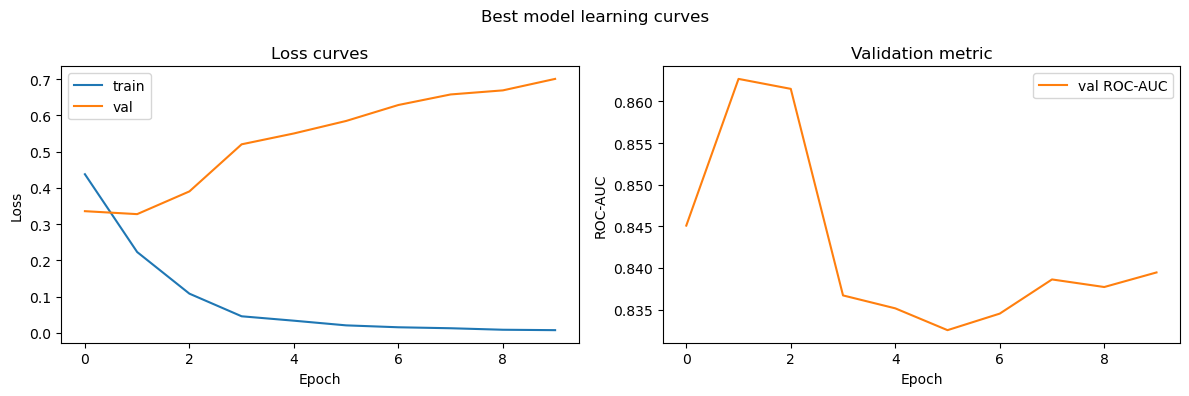

In [22]:
# --- Exercise 7 solution: pick the best run by VALIDATION score ---
best_idx = int(runs_df["best_val_score"].idxmax())
best_run = all_runs[best_idx]
print("Selected run by validation ROC-AUC:")
print(runs_df.loc[best_idx])

plot_learning_curves(best_run["history"], title="Best model learning curves")

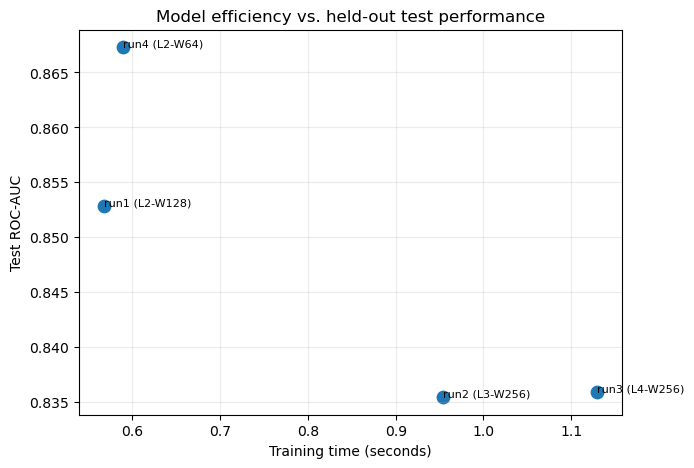

In [23]:
# --- Exercise 7 solution: efficiency vs. performance (Pareto-front context) ---
plt.figure(figsize=(7, 5))
plt.scatter(runs_df["train_time_sec"], runs_df["test_score"], s=80)
for _, row in runs_df.iterrows():
    label = f"run{int(row['run_idx'])} (L{int(row['hidden_layers'])}-W{int(row['hidden_width'])})"
    plt.annotate(label, (row["train_time_sec"], row["test_score"]), fontsize=8)
plt.xlabel("Training time (seconds)")
plt.ylabel("Test ROC-AUC")
plt.title("Model efficiency vs. held-out test performance")
plt.grid(alpha=0.25)
plt.show()

---
## Exercise 8 — Conclusions

1. Summarize the best run's hyperparameters and scores, and connect it back to Exercise 5: does the winning configuration's size make sense given how much labeled data was available for `CFG.target_col`?
2. Plot the ROC curve for the best model's test predictions, alongside the scalar ROC-AUC already reported.
3. Submit the final run to the class leaderboard for the Pareto-front analysis.

Best configuration for SR-MMP:
hidden_layers         2
hidden_width        128
activation         relu
dropout             0.1
optimizer          adam
learning_rate     0.001
param_count      278913
Name: 0, dtype: object

val ROC-AUC:  0.863
test ROC-AUC: 0.853

For comparison, the capacity sweep (Exercise 5) trained on the same ~4062 labeled molecules showed the train/val loss gap widening as parameter count grew — keep that in mind when judging whether the best run's size is actually earning its complexity, or just fitting noise in a modest-sized training set.


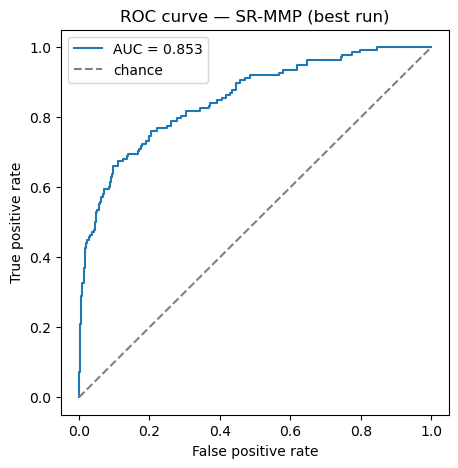

In [24]:
# --- Exercise 8 solution: summary + ROC curve for the best model ---
print(f"Best configuration for {CFG.target_col}:")
print(runs_df.loc[best_idx, ["hidden_layers", "hidden_width", "activation", "dropout", "optimizer", "learning_rate", "param_count"]])
print(f"\nval ROC-AUC:  {best_run['best_val_score']:.3f}")
print(f"test ROC-AUC: {best_run['test_score']:.3f}")
print(f"\nFor comparison, the capacity sweep (Exercise 5) trained on the same ~{x_train.shape[0]} labeled molecules "
      f"showed the train/val loss gap widening as parameter count grew — keep that in mind when judging whether "
      f"the best run's size is actually earning its complexity, or just fitting noise in a modest-sized training set.")

fpr, tpr, _ = roc_curve(best_run["y_true_test"], best_run["y_pred_test"])
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {best_run['test_score']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve — {CFG.target_col} (best run)")
plt.legend()
plt.show()

In [25]:
# --- Exercise 8 solution: build the standardized leaderboard payload ---
# `payload` bundles the winning run's config and scores into the exact field
# set expected by `leaderboard/results_schema.csv`, so every team's submission
# is comparable (used for the class Pareto-front analysis of performance vs.
# training cost).

def utc_now_iso():
    """Current UTC time as an ISO-8601 string (e.g. '2026-08-01T12:00:00Z')."""
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z")

run_id = f"{CFG.student_or_team.lower().replace(' ', '_')}_{int(time.time())}"
payload = {
    "run_id": run_id,
    "timestamp_utc": utc_now_iso(),
    "student_or_team": CFG.student_or_team,
    "dataset_name": "tox21",
    "task_type": "binary_classification",
    "split_version": CFG.split_version,
    "model_family": "MLP",
    "hidden_layers": int(best_run["hidden_layers"]),
    "hidden_width": int(best_run["hidden_width"]),
    "activation": best_run["activation"],
    "dropout": float(best_run["dropout"]),
    "optimizer": best_run["optimizer"],
    "learning_rate": float(best_run["learning_rate"]),
    "batch_size": int(best_run["batch_size"]),
    "weight_decay": float(best_run["weight_decay"]),
    "epochs_trained": int(best_run["epochs_trained"]),
    "param_count": int(best_run["param_count"]),
    "train_time_sec": float(best_run["train_time_sec"]),
    "best_val_score": float(best_run["best_val_score"]),
    "test_score": float(best_run["test_score"]),
    "metric_name": CFG.metric_name,
    "device": str(DEVICE),
    "seed": int(SEED),
    "notebook_version": CFG.notebook_version,
    "notes": f"fixed_split_final_submission:{CFG.target_col}",
}

print(json.dumps(payload, indent=2))

{
  "run_id": "team_xx_1785730560",
  "timestamp_utc": "2026-08-03T04:16:00Z",
  "student_or_team": "Team XX",
  "dataset_name": "tox21",
  "task_type": "binary_classification",
  "split_version": "v1",
  "model_family": "MLP",
  "hidden_layers": 2,
  "hidden_width": 128,
  "activation": "relu",
  "dropout": 0.1,
  "optimizer": "adam",
  "learning_rate": 0.001,
  "batch_size": 128,
  "weight_decay": 0.0001,
  "epochs_trained": 10,
  "param_count": 278913,
  "train_time_sec": 0.5673489570617676,
  "best_val_score": 0.8627043913241197,
  "test_score": 0.852887676216462,
  "metric_name": "roc_auc",
  "device": "cpu",
  "seed": 42,
  "notebook_version": "nn_tutorial_v2_tox21",
  "notes": "fixed_split_final_submission:SR-MMP"
}


In [26]:
# --- Exercise 8 solution: write local submission artifacts ---
# Uses the shared `submit_payload.py` helper (also used by the leaderboard
# backend) so the JSON/CSV format is validated the same way everywhere.
import importlib.util

helper_path = Path(PATHS.helper_py)
if not helper_path.exists():
    raise FileNotFoundError(f"Leaderboard helper not found: {helper_path}")

spec = importlib.util.spec_from_file_location("submit_payload", helper_path)
submit_payload = importlib.util.module_from_spec(spec)
spec.loader.exec_module(submit_payload)

out_dir = Path("./neural-networks-mlp/leaderboard/submissions")
out_dir.mkdir(parents=True, exist_ok=True)
json_path = out_dir / f"{payload['run_id']}.json"
csv_log_path = out_dir / "local_leaderboard_log.csv"

submit_payload.write_payload_json(payload, json_path)
submit_payload.append_payload_csv(payload, csv_log_path)

print(f"Wrote JSON: {json_path}")
print(f"Appended CSV log: {csv_log_path}")

Wrote JSON: neural-networks-mlp/leaderboard/submissions/team_xx_1785730560.json
Appended CSV log: neural-networks-mlp/leaderboard/submissions/local_leaderboard_log.csv


In [27]:
# --- Exercise 8 solution: optional — submit to a shared leaderboard endpoint ---
# Set APPS_SCRIPT_URL to your deployed Google Apps Script web app URL to post
# `payload` there directly. Leave it empty to skip (e.g. if you're only
# submitting the local JSON/CSV files written above).

APPS_SCRIPT_URL = ""

if APPS_SCRIPT_URL:
    import requests
    resp = requests.post(APPS_SCRIPT_URL, json=payload, timeout=30)
    print("Status:", resp.status_code)
    print("Response:", resp.text[:500])
else:
    print("APPS_SCRIPT_URL is empty. Skipping remote submission.")

APPS_SCRIPT_URL is empty. Skipping remote submission.


---
## Exercise 9 (Advanced) — Multi-task Tox21

So far each model only ever saw one Tox21 assay. But the 12 assays share underlying chemistry (e.g. several are nuclear-receptor pathways) — a model with a shared hidden trunk and one output head per task can potentially learn a better shared representation, especially useful when any single task's labeled set is small.

The catch: the label matrix is sparse (Exercise 1), so the loss must **mask out untested (task, molecule) pairs** rather than treating a missing label as a real 0.

1. Build `(X, Y, W)` for each fixed split, over *all* molecules regardless of `CFG.target_col` — `Y` is the 12-task label matrix (missing filled with 0) and `W` is a same-shaped mask (1 where a label exists, 0 otherwise).
2. Reuse `MolecularMLP` with `out_dim=len(TOX21_TASKS)`, and write a masked version of the training/evaluation loop: `BCEWithLogitsLoss(reduction="none")` multiplied by the mask, averaged only over valid labels.
3. Train it, report a per-task test ROC-AUC table plus the mean across tasks, and compare the shared `CFG.target_col` task's multi-task score against its Exercise 7 single-task score.

In [28]:
# --- Exercise 9 solution: build multi-task (X, Y, W) arrays over ALL molecules ---
# Reuses the same fixed splits (by sample_id) and the same fp_ feature matrix
# from Exercise 2 — but unlike Exercise 4, rows are NOT dropped for missing
# CFG.target_col labels, since every task now has its own mask.

def build_multitask_split(df, tasks, sample_ids):
    sub = df[df["sample_id"].isin(sample_ids)]
    X = sub[fp_cols].values.astype(np.float32)
    y_raw = sub[tasks].values.astype(np.float32)
    W = (~np.isnan(y_raw)).astype(np.float32)
    Y = np.nan_to_num(y_raw, nan=0.0)
    return X, Y, W

train_ids_all = _read_split_ids(PATHS.train_split_csv)
val_ids_all = _read_split_ids(PATHS.val_split_csv)
test_ids_all = _read_split_ids(PATHS.test_split_csv)

X_train_mt, Y_train_mt, W_train_mt = build_multitask_split(df, TOX21_TASKS, train_ids_all)
X_val_mt, Y_val_mt, W_val_mt = build_multitask_split(df, TOX21_TASKS, val_ids_all)
X_test_mt, Y_test_mt, W_test_mt = build_multitask_split(df, TOX21_TASKS, test_ids_all)

mt_scaler = StandardScaler()
X_train_mt = mt_scaler.fit_transform(X_train_mt)
X_val_mt = mt_scaler.transform(X_val_mt)
X_test_mt = mt_scaler.transform(X_test_mt)

print(f"Multi-task splits: train {X_train_mt.shape}, val {X_val_mt.shape}, test {X_test_mt.shape}")
print(f"Labels per molecule available on average: {W_train_mt.sum(axis=1).mean():.1f} / {len(TOX21_TASKS)} tasks")

Multi-task splits: train (5475, 2048), val (1174, 2048), test (1174, 2048)
Labels per molecule available on average: 9.9 / 12 tasks


In [29]:
# --- Exercise 9 solution: tensors, loaders, and the masked training/eval loop ---
mt_train_loader = DataLoader(TensorDataset(
    torch.tensor(X_train_mt, dtype=torch.float32),
    torch.tensor(Y_train_mt, dtype=torch.float32),
    torch.tensor(W_train_mt, dtype=torch.float32),
), batch_size=128, shuffle=True)

mt_val_loader = DataLoader(TensorDataset(
    torch.tensor(X_val_mt, dtype=torch.float32),
    torch.tensor(Y_val_mt, dtype=torch.float32),
    torch.tensor(W_val_mt, dtype=torch.float32),
), batch_size=256, shuffle=False)

mt_test_loader = DataLoader(TensorDataset(
    torch.tensor(X_test_mt, dtype=torch.float32),
    torch.tensor(Y_test_mt, dtype=torch.float32),
    torch.tensor(W_test_mt, dtype=torch.float32),
), batch_size=256, shuffle=False)

def train_one_epoch_multitask(model, loader, optimizer):
    """Same idea as `train_one_epoch`, but the per-element BCE loss is
    multiplied by the mask before averaging, so untested (molecule, task)
    pairs contribute zero gradient."""
    model.train()
    bce = nn.BCEWithLogitsLoss(reduction="none")
    total_loss, total_count = 0.0, 0.0
    for xb, yb, wb in loader:
        xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss_elem = bce(logits, yb) * wb
        loss = loss_elem.sum() / wb.sum().clamp(min=1)
        loss.backward()
        optimizer.step()
        total_loss += loss_elem.sum().item()
        total_count += wb.sum().item()
    return total_loss / max(total_count, 1)

@torch.no_grad()
def evaluate_multitask(model, loader, tasks):
    """Per-task ROC-AUC, computed only over rows where that task's mask is 1."""
    model.eval()
    all_probs, all_y, all_w = [], [], []
    for xb, yb, wb in loader:
        xb = xb.to(DEVICE)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        all_probs.append(probs)
        all_y.append(yb.numpy())
        all_w.append(wb.numpy())
    probs = np.concatenate(all_probs)
    y = np.concatenate(all_y)
    w = np.concatenate(all_w)

    per_task_auc = {}
    for i, task in enumerate(tasks):
        mask = w[:, i] > 0
        if mask.sum() > 1 and len(np.unique(y[mask, i])) > 1:
            per_task_auc[task] = roc_auc_score(y[mask, i], probs[mask, i])
        else:
            per_task_auc[task] = np.nan
    mean_auc = float(np.nanmean(list(per_task_auc.values())))
    return per_task_auc, mean_auc

In [30]:
# --- Exercise 9 solution: train the multi-task model ---
mt_model = MolecularMLP(
    in_dim=X_train_mt.shape[1], hidden_layers=2, hidden_width=256,
    dropout=0.2, activation="relu", out_dim=len(TOX21_TASKS),
).to(DEVICE)
mt_optimizer = torch.optim.Adam(mt_model.parameters(), lr=1e-3, weight_decay=1e-4)

mt_epochs, mt_patience = 40, 8
best_mean_auc, best_state, no_improve = -np.inf, None, 0

for epoch in range(mt_epochs):
    train_loss = train_one_epoch_multitask(mt_model, mt_train_loader, mt_optimizer)
    _, val_mean_auc = evaluate_multitask(mt_model, mt_val_loader, TOX21_TASKS)

    if val_mean_auc > best_mean_auc:
        best_mean_auc = val_mean_auc
        best_state = {k: v.detach().cpu().clone() for k, v in mt_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= mt_patience:
        break

if best_state is not None:
    mt_model.load_state_dict(best_state)
print(f"Multi-task training done: best val mean ROC-AUC = {best_mean_auc:.3f}")

Multi-task training done: best val mean ROC-AUC = 0.790


In [31]:
# --- Exercise 9 solution: per-task test ROC-AUC, and comparison to the single-task baseline ---
per_task_test_auc, mean_test_auc = evaluate_multitask(mt_model, mt_test_loader, TOX21_TASKS)

mt_summary = pd.DataFrame({
    "task": TOX21_TASKS,
    "multitask_test_auc": [per_task_test_auc[t] for t in TOX21_TASKS],
}).sort_values("multitask_test_auc", ascending=False).reset_index(drop=True)
print(mt_summary)
print(f"\nMean test ROC-AUC across all 12 tasks: {mean_test_auc:.3f}")

print(f"\n{CFG.target_col} — single-task test ROC-AUC (Exercise 7 best run): {best_run['test_score']:.3f}")
print(f"{CFG.target_col} — multi-task test ROC-AUC:                        {per_task_test_auc[CFG.target_col]:.3f}")

# This is exploratory: the shared leaderboard schema (results_schema.csv) expects
# one score per submission, so we don't push this multi-task run to the same
# leaderboard as Exercise 8's primary single-task submission. If you want to log
# it anyway, reuse the Exercise 8 payload cells with metric_name="mean_roc_auc",
# test_score=mean_test_auc, and a notes flag marking it as the multi-task variant.

             task  multitask_test_auc
0          NR-AhR            0.872794
1          SR-MMP            0.866560
2        SR-ATAD5            0.857760
3          SR-p53            0.832770
4       NR-AR-LBD            0.830818
5    NR-Aromatase            0.826378
6          SR-ARE            0.792097
7       NR-ER-LBD            0.791186
8           NR-AR            0.756405
9          SR-HSE            0.744925
10  NR-PPAR-gamma            0.720042
11          NR-ER            0.701101

Mean test ROC-AUC across all 12 tasks: 0.799

SR-MMP — single-task test ROC-AUC (Exercise 7 best run): 0.853
SR-MMP — multi-task test ROC-AUC:                        0.867


---
## Further Reading

- **Huang, Xia et al. (2016)** — *Tox21 Challenge to Build Predictive Models of Nuclear Receptor and Stress Response Pathways as Mediated by Exposure to Environmental Chemicals and Drugs* — Front. Environ. Sci. — overview of the Tox21 challenge and dataset.
- **Mayr et al. (2016)** — *DeepTox: Toxicity Prediction using Deep Learning* — Front. Environ. Sci. 3, 80 — the original deep multi-task model benchmarked on Tox21.
- **Rogers & Hahn (2010)** — *Extended-Connectivity Fingerprints* — J. Chem. Inf. Model. 50, 742 — the ECFP/Morgan fingerprint reference.
- **Ramsundar et al. (2015)** — *Massively Multitask Networks for Drug Discovery* — arXiv:1502.02072 — motivates the multi-task extension in Exercise 9.
- **[Molecular Toxicity Prediction using ML](https://www.kaggle.com/code/gyanendrachaubey/molecular-toxicity-prediction-using-ml)** (Kaggle, gyanendrachaubey) — visualization inspiration for this notebook's EDA and evaluation plots.